# MICROPROJECT - Solution Template

Fill in each section as you work through the steps.

In [1]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import pandas as pd
import numpy as np

np.random.seed(7)

n = 30

data = {
    "price_inr": np.random.randint(2000000, 3100000, n),
    "sqft": np.random.randint(450, 1100, n),
    "floors": np.random.choice([1, 1, 1, 2], n),
    "property_type": ["Independent House"] * n,
    "age_years": np.random.randint(1, 25, n),
    "parking": np.random.choice([0, 1], n, p=[0.4, 0.6]),
    "area_name": ["Vidi Gharkul, Solapur"] * n
}

df = pd.DataFrame(data)
df.to_csv("vidi_gharkul_local_houses.csv", index=False)

print("✅ Dataset created:", df.shape)
df.head()

✅ Dataset created: (30, 7)


,price_inr,sqft,floors,property_type,age_years,parking,area_name
0,2585903,972,1,Independent House,9,0,"Vidi Gharkul, Solapur"
1,2573977,898,2,Independent House,23,0,"Vidi Gharkul, Solapur"
2,2535030,767,1,Independent House,7,0,"Vidi Gharkul, Solapur"
3,2839891,841,1,Independent House,22,0,"Vidi Gharkul, Solapur"
4,2079463,601,1,Independent House,7,0,"Vidi Gharkul, Solapur"


In [3]:
# Step 2: Load data
df = pd.read_csv("vidi_gharkul_local_houses.csv")
print(df.head())
print(df.info())

   price_inr  sqft  floors      property_type  age_years  parking  \
0    2585903   972       1  Independent House          9        0   
1    2573977   898       2  Independent House         23        0   
2    2535030   767       1  Independent House          7        0   
3    2839891   841       1  Independent House         22        0   
4    2079463   601       1  Independent House          7        0   

               area_name  
0  Vidi Gharkul, Solapur  
1  Vidi Gharkul, Solapur  
2  Vidi Gharkul, Solapur  
3  Vidi Gharkul, Solapur  
4  Vidi Gharkul, Solapur  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   price_inr      30 non-null     int64 
 1   sqft           30 non-null     int64 
 2   floors         30 non-null     int64 
 3   property_type  30 non-null     object
 4   age_years      30 non-null     int64 
 5   parking        

In [4]:
# Step 3: Explore data
print(df.describe())
print("\nMissing values:\n", df.isna().sum())

          price_inr         sqft     floors  age_years    parking
count  3.000000e+01    30.000000  30.000000  30.000000  30.000000
mean   2.461588e+06   754.066667   1.366667  12.266667   0.633333
std    3.148129e+05   191.972328   0.490133   6.564971   0.490133
min    2.027692e+06   469.000000   1.000000   1.000000   0.000000
25%    2.196570e+06   574.750000   1.000000   7.000000   0.000000
50%    2.470071e+06   783.000000   1.000000  11.000000   1.000000
75%    2.643526e+06   922.750000   2.000000  18.000000   1.000000
max    3.014310e+06  1081.000000   2.000000  23.000000   1.000000

Missing values:
 price_inr        0
sqft             0
floors           0
property_type    0
age_years        0
parking          0
area_name        0
dtype: int64


In [5]:
# Step 4: Implement solution
# Remove duplicates
df_clean = df.drop_duplicates()

# Handle missing values (numeric columns)
import numpy as np
num_cols = df_clean.select_dtypes(include=np.number).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Remove extreme outliers (top 1% prices)
upper = df_clean["price_inr"].quantile(0.99)
df_clean = df_clean[df_clean["price_inr"] <= upper]

print("\n--- Cleaned Dataset Shape ---")
print(df_clean.shape)

# Save curated dataset
df_clean.to_csv("vidi_gharkul_local_houses_clean.csv", index=False)
print("Saved curated dataset: vidi_gharkul_local_houses_clean.csv")


--- Cleaned Dataset Shape ---
(29, 7)
Saved curated dataset: vidi_gharkul_local_houses_clean.csv


In [6]:
# Step 5: Evaluate results
print("Missing values (raw):")
print(df.isna().sum())

print("\nMissing values (cleaned):")
print(df_clean.isna().sum())

print("\nShape (raw):", df.shape)
print("Shape (cleaned):", df_clean.shape)

print("\nPrice stats (raw):")
print(df["price_inr"].describe())

print("\nPrice stats (cleaned):")
print(df_clean["price_inr"].describe())

Missing values (raw):
price_inr        0
sqft             0
floors           0
property_type    0
age_years        0
parking          0
area_name        0
dtype: int64

Missing values (cleaned):
price_inr        0
sqft             0
floors           0
property_type    0
age_years        0
parking          0
area_name        0
dtype: int64

Shape (raw): (30, 7)
Shape (cleaned): (29, 7)

Price stats (raw):
count    3.000000e+01
mean     2.461588e+06
std      3.148129e+05
min      2.027692e+06
25%      2.196570e+06
50%      2.470071e+06
75%      2.643526e+06
max      3.014310e+06
Name: price_inr, dtype: float64

Price stats (cleaned):
count    2.900000e+01
mean     2.442529e+06
std      3.022577e+05
min      2.027692e+06
25%      2.185693e+06
50%      2.409431e+06
75%      2.640432e+06
max      2.964809e+06
Name: price_inr, dtype: float64


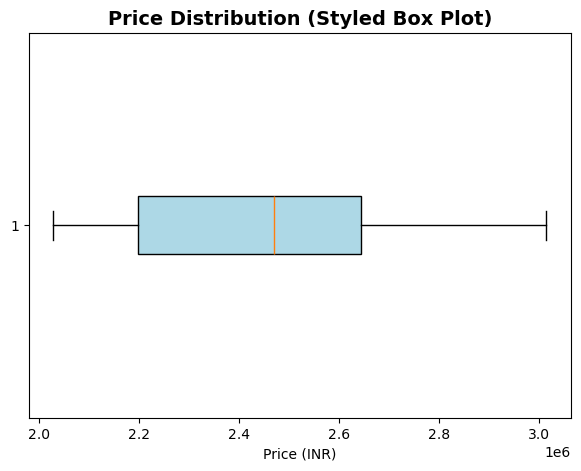

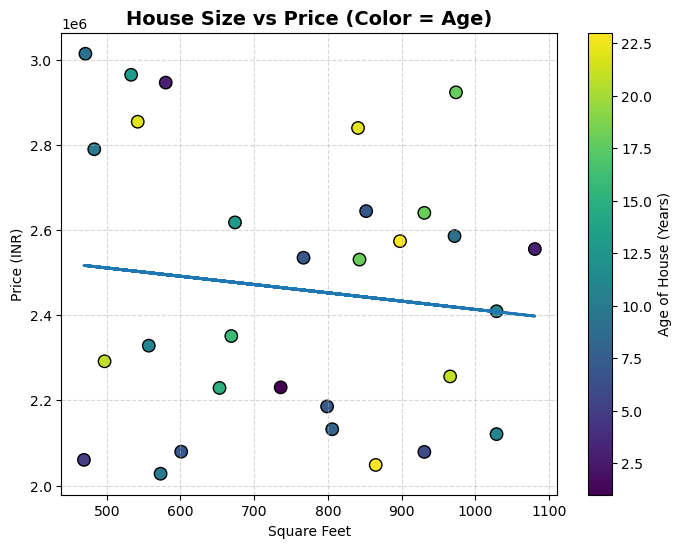

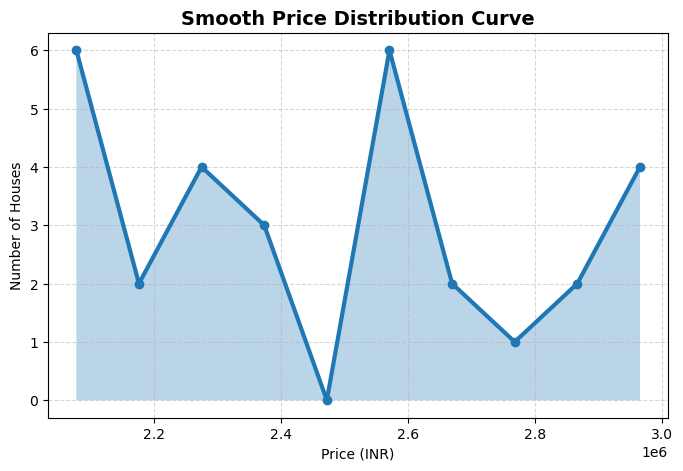

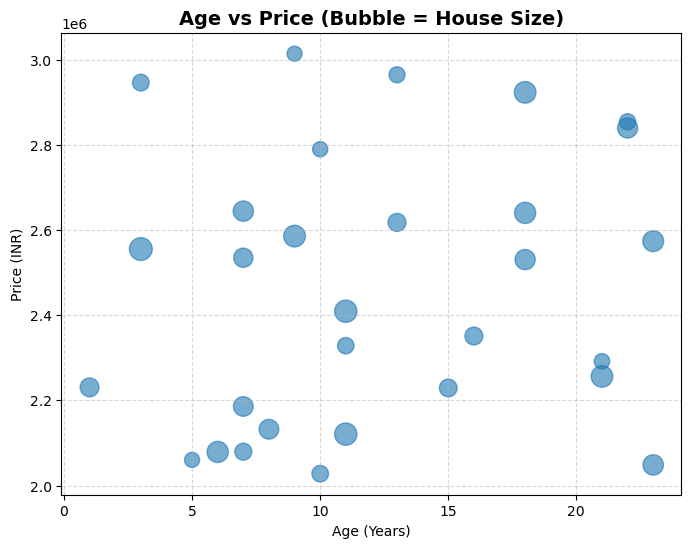

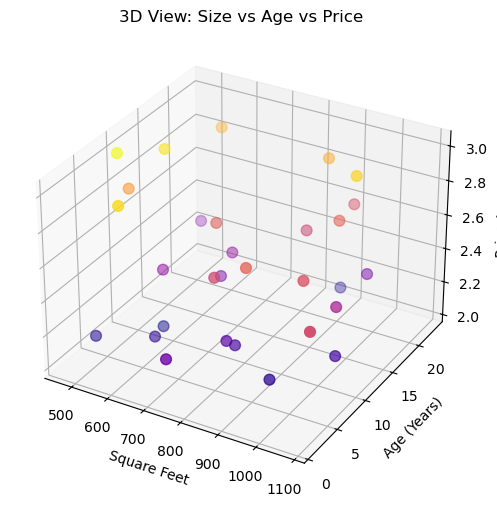

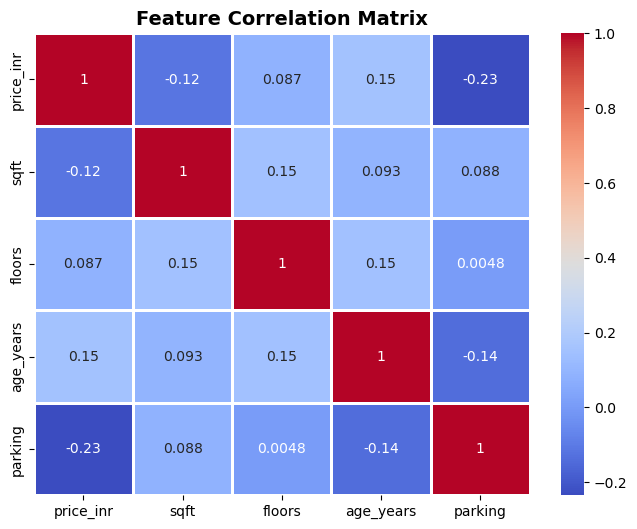

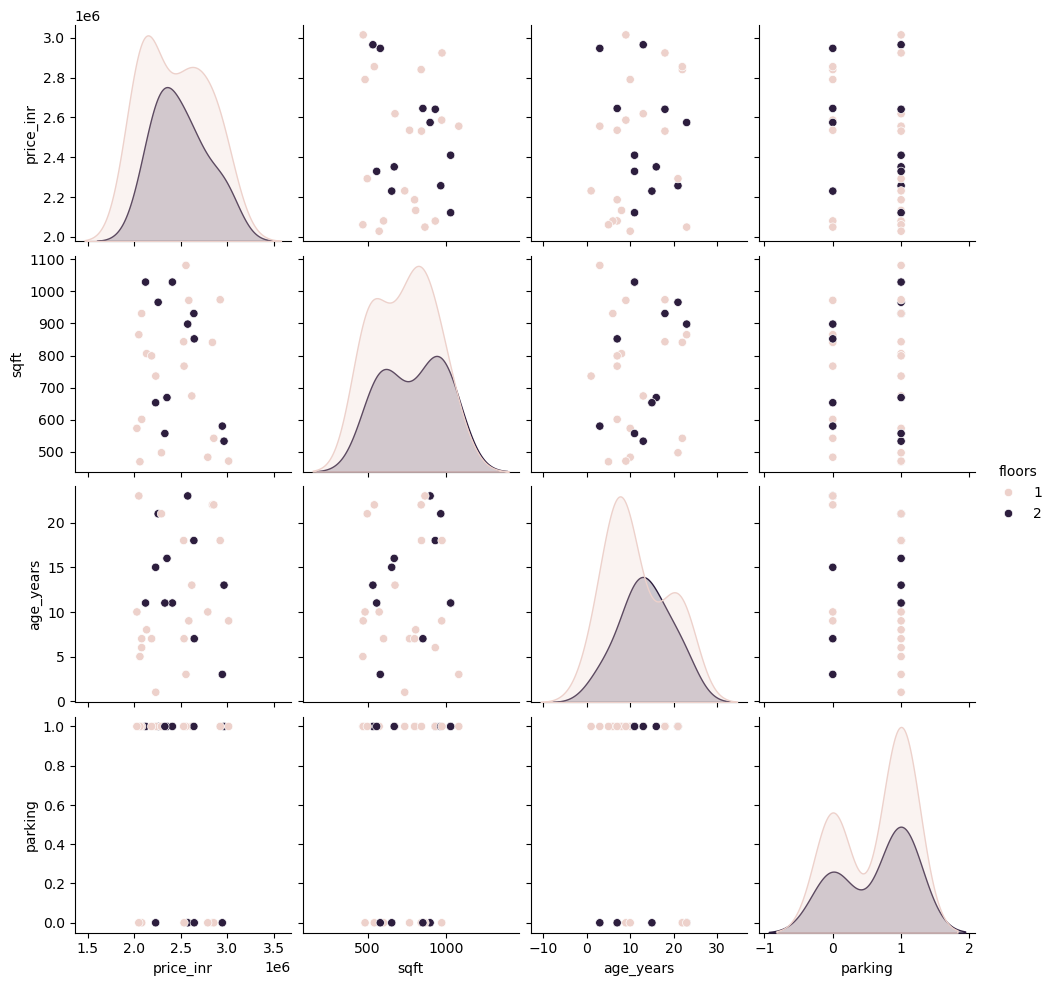

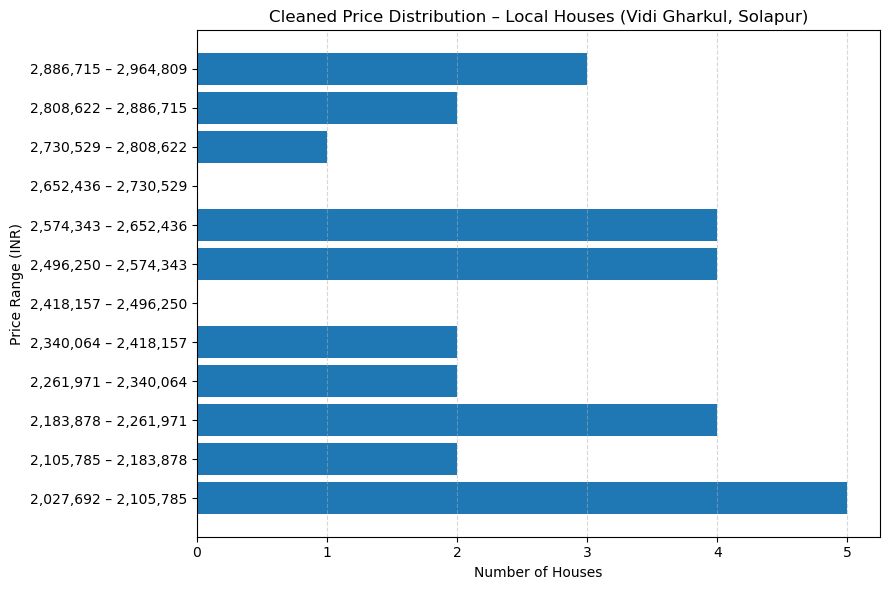

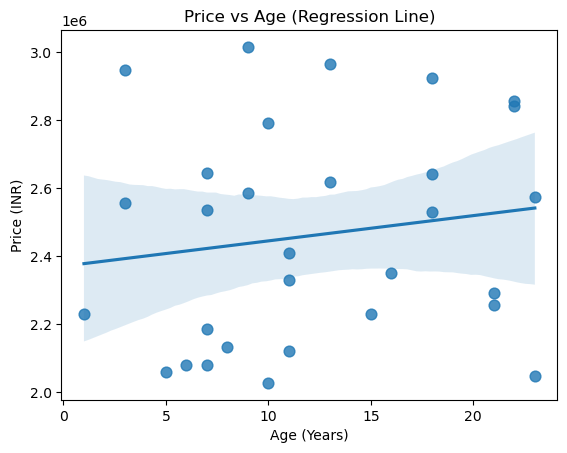

In [7]:
# Visualizations
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(7,5))
plt.boxplot(df["price_inr"],
            vert=False,
            patch_artist=True,
            boxprops=dict(facecolor="lightblue"))
plt.title("Price Distribution (Styled Box Plot)", fontsize=14, fontweight="bold")
plt.xlabel("Price (INR)")
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(df["sqft"], df["price_inr"],
            c=df["age_years"], cmap="viridis",
            s=80, edgecolors="black")
# Trend line
z = np.polyfit(df["sqft"], df["price_inr"], 1)
p = np.poly1d(z)
plt.plot(df["sqft"], p(df["sqft"]), linewidth=2)
plt.colorbar(label="Age of House (Years)")
plt.title("House Size vs Price (Color = Age)", fontsize=14, fontweight="bold")
plt.xlabel("Square Feet")
plt.ylabel("Price (INR)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

hist, bins = np.histogram(df["price_inr"], bins=10)
bin_centers = 0.5 * (bins[:-1] + bins[1:])
plt.figure(figsize=(8,5))
plt.plot(bin_centers, hist, marker='o', linestyle='-', linewidth=3)
plt.fill_between(bin_centers, hist, alpha=0.3)
plt.title("Smooth Price Distribution Curve", fontsize=14, fontweight="bold")
plt.xlabel("Price (INR)")
plt.ylabel("Number of Houses")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(df["age_years"],
            df["price_inr"],
            s=df["sqft"]/4,
            alpha=0.6)
plt.title("Age vs Price (Bubble = House Size)", fontsize=14, fontweight="bold")
plt.xlabel("Age (Years)")
plt.ylabel("Price (INR)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df["sqft"], df["age_years"], df["price_inr"],
           c=df["price_inr"], cmap="plasma", s=60)
ax.set_xlabel("Square Feet")
ax.set_ylabel("Age (Years)")
ax.set_zlabel("Price (INR)")
ax.set_title("3D View: Size vs Age vs Price")
plt.show()

import seaborn as sns
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm",
            linewidths=1)
plt.title("Feature Correlation Matrix", fontsize=14, fontweight="bold")
plt.show()

sns.pairplot(df, hue="floors")
plt.show()

# Cleaned price distribution
hist, bins = np.histogram(df_clean["price_inr"], bins=12)
# Create readable labels for price ranges
labels = [f"{int(bins[i]):,} – {int(bins[i+1]):,}" for i in range(len(bins)-1)]
# Plot horizontal bar chart
plt.figure(figsize=(9, 6))
plt.barh(labels, hist)
plt.title("Cleaned Price Distribution – Local Houses (Vidi Gharkul, Solapur)")
plt.xlabel("Number of Houses")
plt.ylabel("Price Range (INR)")
plt.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

sns.regplot(x="age_years", y="price_inr", data=df, scatter_kws={'s':60})
plt.title("Price vs Age (Regression Line)")
plt.xlabel("Age (Years)")
plt.ylabel("Price (INR)")
plt.show()

# from sklearn.linear_model import LinearRegression
# X = df[["sqft", "age_years", "floors", "parking"]]
# y = df["price_inr"]
# model = LinearRegression()
# model.fit(X, y)
# importance = pd.Series(model.coef_, index=X.columns)
# plt.figure(figsize=(7,5))
# importance.sort_values().plot(kind="barh")
# plt.title("Feature Importance (Linear Regression Coefficients)")
# plt.xlabel("Impact on Price")
# plt.show()


In [8]:
# Step 6: Train House Price Prediction Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

# Features & target
X = df_clean[["sqft", "age_years", "floors", "parking"]]
y = df_clean["price_inr"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 197033.12511211354
R2 Score: -0.3485096476690055
